 ## House Price Predictor

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
housing = fetch_california_housing(as_frame=True)

In [3]:
df = housing.frame

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df['MedInc']

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: MedInc, Length: 20640, dtype: float64

In [7]:
df['MedInc'].value_counts()

MedInc
3.1250     49
15.0001    49
2.8750     46
2.6250     44
4.1250     44
           ..
4.0774      1
4.1767      1
6.1814      1
6.4319      1
2.0943      1
Name: count, Length: 12928, dtype: int64

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
%matplotlib inline

In [10]:
import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

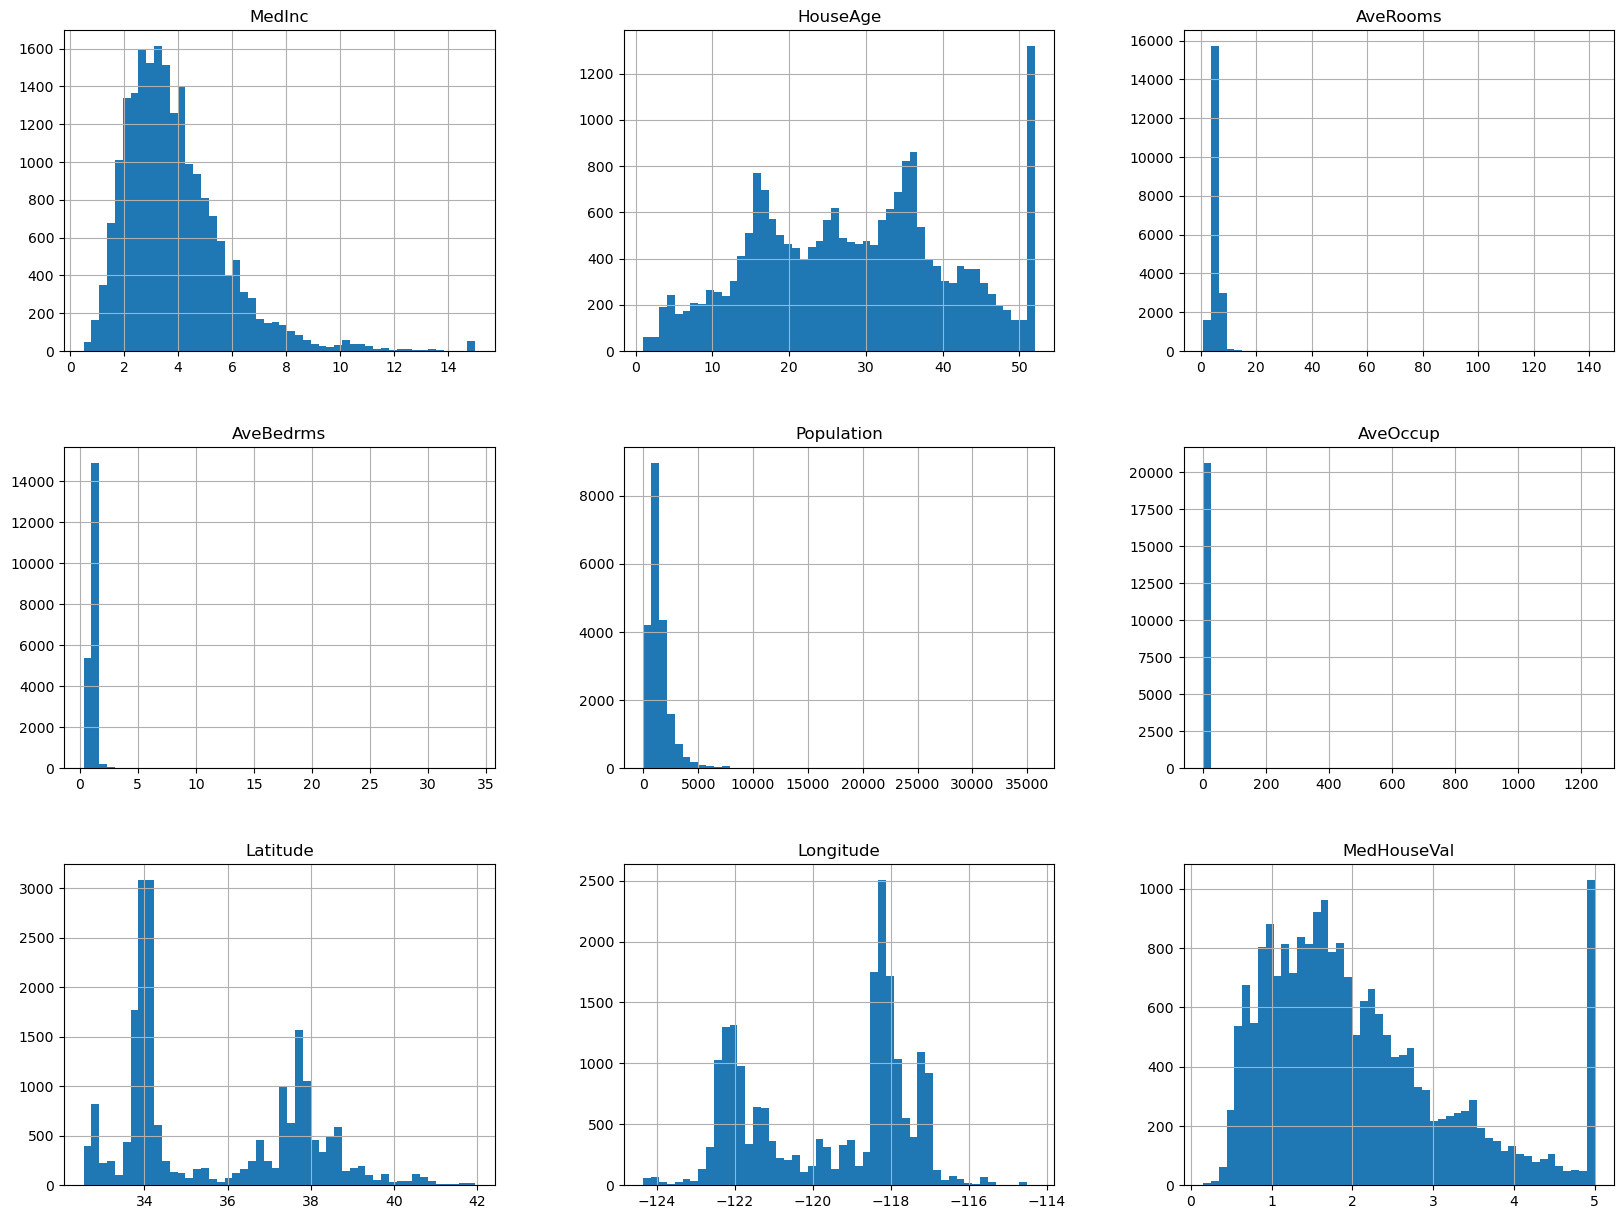

In [11]:
df.hist(bins=50, figsize=(20, 15))

## Train -state Splitting

In [12]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [13]:
print(len(train_set))
print(len(test_set))

16512
4128


In [14]:
import numpy as np

df["income_cat"] = np.ceil(df["MedInc"] / 1.5)

In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [16]:
strat_test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 5251 to 2398
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       4128 non-null   float64
 1   HouseAge     4128 non-null   float64
 2   AveRooms     4128 non-null   float64
 3   AveBedrms    4128 non-null   float64
 4   Population   4128 non-null   float64
 5   AveOccup     4128 non-null   float64
 6   Latitude     4128 non-null   float64
 7   Longitude    4128 non-null   float64
 8   MedHouseVal  4128 non-null   float64
 9   income_cat   4128 non-null   float64
dtypes: float64(10)
memory usage: 354.8 KB


In [17]:
strat_test_set['income_cat'].value_counts()



income_cat
3.0     1447
2.0     1316
4.0      728
5.0      285
1.0      164
6.0      106
7.0       38
8.0       21
11.0      10
9.0       10
10.0       3
Name: count, dtype: int64

In [18]:
strat_train_set['income_cat'].value_counts()


income_cat
3.0     5789
2.0     5265
4.0     2911
5.0     1138
1.0      658
6.0      426
7.0      151
8.0       84
9.0       40
11.0      39
10.0      11
Name: count, dtype: int64

In [19]:
 # 95/7

In [20]:
# 376/28

In [21]:
strat_train_set.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,income_cat
17606,2.7042,38.0,4.625369,1.035398,710.0,2.094395,37.29,-121.89,2.86600,2.0
15698,14.2959,52.0,8.172727,0.872727,304.0,2.763636,37.79,-122.46,5.00001,10.0
14650,2.8621,31.0,4.225108,1.019481,936.0,2.025974,32.77,-117.20,1.96900,2.0
3230,1.8839,25.0,5.232295,1.050992,1460.0,4.135977,36.31,-119.61,0.46300,2.0
3555,3.0347,17.0,4.505810,1.042379,4459.0,3.047847,34.23,-118.59,2.54500,3.0


In [22]:
df = strat_train_set.copy()

## Looking for correlation

In [23]:
corr_matrix = df.corr()

In [24]:
corr_matrix['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.687474
income_cat     0.667208
AveRooms       0.145750
HouseAge       0.111770
AveOccup      -0.021844
Population    -0.024765
AveBedrms     -0.042988
Longitude     -0.045056
Latitude      -0.144684
Name: MedHouseVal, dtype: float64

array([[<Axes: xlabel='MedHouseVal', ylabel='MedHouseVal'>,
        <Axes: xlabel='MedInc', ylabel='MedHouseVal'>,
        <Axes: xlabel='income_cat', ylabel='MedHouseVal'>,
        <Axes: xlabel='Latitude', ylabel='MedHouseVal'>],
       [<Axes: xlabel='MedHouseVal', ylabel='MedInc'>,
        <Axes: xlabel='MedInc', ylabel='MedInc'>,
        <Axes: xlabel='income_cat', ylabel='MedInc'>,
        <Axes: xlabel='Latitude', ylabel='MedInc'>],
       [<Axes: xlabel='MedHouseVal', ylabel='income_cat'>,
        <Axes: xlabel='MedInc', ylabel='income_cat'>,
        <Axes: xlabel='income_cat', ylabel='income_cat'>,
        <Axes: xlabel='Latitude', ylabel='income_cat'>],
       [<Axes: xlabel='MedHouseVal', ylabel='Latitude'>,
        <Axes: xlabel='MedInc', ylabel='Latitude'>,
        <Axes: xlabel='income_cat', ylabel='Latitude'>,
        <Axes: xlabel='Latitude', ylabel='Latitude'>]], dtype=object)

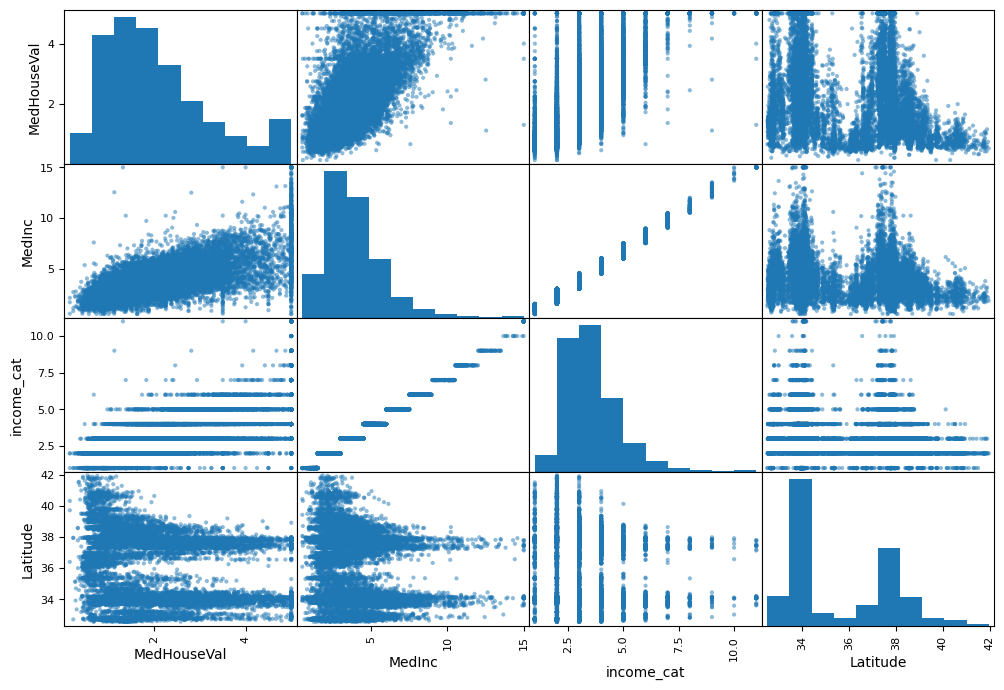

In [25]:
from pandas.plotting import scatter_matrix
attributes = ["MedHouseVal","MedInc", "income_cat","Latitude"]
scatter_matrix(df[attributes], figsize = (12,8))

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

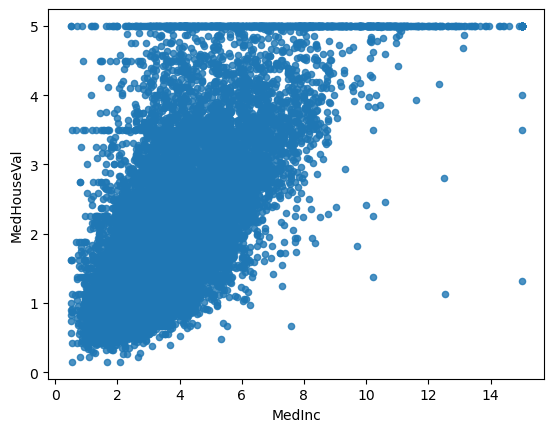

In [26]:
df.plot(kind="scatter", x="MedInc", y="MedHouseVal", alpha=0.8)

### Trying out Attribute Combinations

In [27]:
df["RoomsPerIncome"] = df["AveRooms"] / df["MedInc"]

In [28]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,income_cat,RoomsPerIncome
17606,2.7042,38.0,4.625369,1.035398,710.0,2.094395,37.29,-121.89,2.86600,2.0,1.710439
15698,14.2959,52.0,8.172727,0.872727,304.0,2.763636,37.79,-122.46,5.00001,10.0,0.571683
14650,2.8621,31.0,4.225108,1.019481,936.0,2.025974,32.77,-117.20,1.96900,2.0,1.476227
3230,1.8839,25.0,5.232295,1.050992,1460.0,4.135977,36.31,-119.61,0.46300,2.0,2.777374
3555,3.0347,17.0,4.505810,1.042379,4459.0,3.047847,34.23,-118.59,2.54500,3.0,1.484763


In [29]:
corr_matrix = df.corr()
corr_matrix['MedHouseVal'].sort_values(ascending=False)



MedHouseVal       1.000000
MedInc            0.687474
income_cat        0.667208
AveRooms          0.145750
HouseAge          0.111770
AveOccup         -0.021844
Population       -0.024765
AveBedrms        -0.042988
Longitude        -0.045056
Latitude         -0.144684
RoomsPerIncome   -0.313804
Name: MedHouseVal, dtype: float64

<Axes: xlabel='RoomsPerIncome', ylabel='MedHouseVal'>

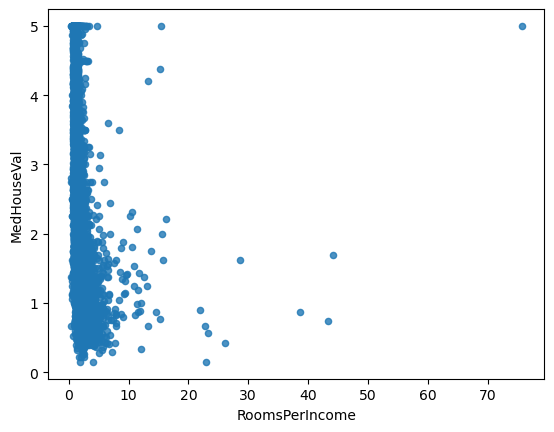

In [30]:
df.plot(kind="scatter", x="RoomsPerIncome", y="MedHouseVal", alpha=0.8)

In [31]:
df_lables = strat_train_set["MedHouseVal"].copy()


In [32]:
df = strat_train_set.drop("MedHouseVal", axis=1)

## Missing Attributes

In [33]:
# to take care of missing attributes, you have three options:
#   1.Get rid of the misssing data points
#   2.Get rid of the whole attributes
#   3.Get the value to some value(0, mean or median)

In [34]:
a = df.dropna(subset=["MedInc"])   # option 1
a.shape

(16512, 9)

In [35]:
df.drop("MedInc", axis=1).shape #option 2
# Note that there is no MedInc column and also note that the original df will remain unchanged

(16512, 8)

In [36]:
median = df["MedInc"].median() #Compute madian for option3

In [37]:
df["MedInc"].fillna(median) #option 3
# Note that the original housing dataform will ramain unchanged

17606     2.7042
15698    14.2959
14650     2.8621
3230      1.8839
3555      3.0347
          ...   
6563      4.9312
12053     2.0682
13908     3.2723
11159     4.0625
15775     3.5750
Name: MedInc, Length: 16512, dtype: float64

In [38]:
df.shape

(16512, 9)

In [39]:
df.describe() # before we started filling missing attributes

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,income_cat
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.873393,28.633721,5.441357,1.098709,1421.965540,3.096439,35.635516,-119.571860,3.093084
std,1.899090,12.582583,2.615368,0.507430,1119.674776,11.584765,2.137953,2.002105,1.303219
min,0.499900,1.000000,1.130435,0.333333,3.000000,0.692308,32.540000,-124.350000,1.000000
25%,2.566775,18.000000,4.441091,1.005803,785.000000,2.431483,33.930000,-121.800000,2.000000
50%,3.540900,29.000000,5.232561,1.048522,1166.000000,2.818681,34.260000,-118.510000,3.000000
75%,4.744475,37.000000,6.057617,1.099207,1720.000000,3.281487,37.720000,-118.010000,4.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,11.000000


In [40]:
import pandas as pd
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
imputer.fit(df)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [41]:
imputer.statistics_

array([ 3.54090000e+00,  2.90000000e+01,  5.23256140e+00,  1.04852164e+00,
        1.16600000e+03,  2.81868054e+00,  3.42600000e+01, -1.18510000e+02,
        3.00000000e+00])

In [42]:
X = imputer.transform(df)

In [43]:
df_tr = pd.DataFrame(X, columns=df.columns)

In [44]:
df_tr.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,income_cat
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.873393,28.633721,5.441357,1.098709,1421.965540,3.096439,35.635516,-119.571860,3.093084
std,1.899090,12.582583,2.615368,0.507430,1119.674776,11.584765,2.137953,2.002105,1.303219
min,0.499900,1.000000,1.130435,0.333333,3.000000,0.692308,32.540000,-124.350000,1.000000
25%,2.566775,18.000000,4.441091,1.005803,785.000000,2.431483,33.930000,-121.800000,2.000000
50%,3.540900,29.000000,5.232561,1.048522,1166.000000,2.818681,34.260000,-118.510000,3.000000
75%,4.744475,37.000000,6.057617,1.099207,1720.000000,3.281487,37.720000,-118.010000,4.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,11.000000


## Scikit-learn Design

Primarily, three types of object
1. Estimaters - It estimate some parameter based on a dataset. Eg. imputer It has a fit method and transform method. Fit method - Fits the dataset and calculates internal parameters
2. Transformers - transform method takes input and returns output based on the learning from fit(). It also has a convenience function called fit_transform() which fits and then transform.
3. Predictors - LinearRegression model is an example of predictor. fit() and predict() are two common function. It also gives score() function which will evaluate the prediction.

## Feature Scalling

 Primarily, two types of feature scaling methods:
1. Min-max scaling(Normalization)
   (value - min)/(max - min)
   sklearn provides a class called MinMaxScaler for this
2. Standardization
   (value - mean)/std
   Sklearn provides a class called Standard Scaler for this

## Creating a Pipeline

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
my_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= "median")),
    #......add as many as you want in your pipeline
    ('std_scaler',StandardScaler()),
])

In [46]:
df_num_tr = my_pipeline.fit_transform(df)

In [50]:
type(df_num_tr)

numpy.ndarray

In [51]:
df_num_tr.shape

(16512, 9)

## Selecting a desired model for House price Prediction

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Features
df = strat_train_set.drop("MedHouseVal", axis=1)

# Labels
df_labels = strat_train_set["MedHouseVal"].copy()

# Pipeline transform
df_num_tr = my_pipeline.fit_transform(df)

# Train model
model = DecisionTreeRegressor()
model.fit(df_num_tr, df_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [58]:
some_data = strat_test_set.drop("MedHouseVal", axis=1).iloc[:5]

In [59]:
some_lables = df_lables.iloc[:5]

In [60]:
some_data = strat_test_set.drop("MedHouseVal", axis=1)

# Align columns exactly
some_data = some_data.reindex(columns=df.columns, fill_value=0)

prepared_data = my_pipeline.transform(some_data)

In [61]:
prepared_data = my_pipeline.transform(some_data)

In [62]:
model.predict(prepared_data)

array([4.771, 2.492, 2.246, ..., 3.148, 1.713, 2.819], shape=(4128,))

In [63]:
list(some_lables)

[2.866, 5.00001, 1.969, 0.463, 2.545]

## Evaluting the model

from sklearn.metrics import mean_squared_error
import numpy as np

df_prediction = model.predict(df_num_tr)

lin_mse = mean_squared_error(df_labels, df_prediction)
lin_rmse = np.sqrt(lin_mse)

print("RMSE:", lin_rmse)

In [66]:
lin_mse

9.392566252813162e-32

## Using better evaluation technique -cross Validation

In [67]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(model, df_num_tr, df_labels,
                         scoring="neg_mean_squared_error", cv=10)

rmse_scores = np.sqrt(-scores)

In [68]:
rmse_scores

array([0.72252317, 0.71794135, 0.74409726, 0.74747357, 0.74825862,
       0.73247434, 0.70955735, 0.72221042, 0.70494019, 0.74660775])

In [69]:
print("Scores:", rmse_scores)
print("Mean:", rmse_scores.mean())
print("Std Dev:", rmse_scores.std())

Scores: [0.72252317 0.71794135 0.74409726 0.74747357 0.74825862 0.73247434
 0.70955735 0.72221042 0.70494019 0.74660775]
Mean: 0.7296084020854448
Std Dev: 0.015574755196957866


## save the model

In [71]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(df_num_tr, df_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
rf_scores = cross_val_score(rf_model, df_num_tr, df_labels,
                           scoring="neg_mean_squared_error", cv=10)

rf_rmse = np.sqrt(-rf_scores)

print("RF RMSE:", rf_rmse.mean())

RF RMSE: 0.5115788620384434


In [73]:
import joblib

joblib.dump(rf_model, "california_rf_model.pkl")
joblib.dump(my_pipeline, "california_pipeline.pkl")

['california_pipeline.pkl']

## Testing the model on test data

In [75]:
# Prepare test set
X_test = strat_test_set.drop("MedHouseVal", axis=1)
y_test = strat_test_set["MedHouseVal"]

# Apply same pipeline
X_test_prepared = my_pipeline.transform(X_test)

# Predict
final_predictions = rf_model.predict(X_test_prepared)

# Calculate RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print("Final Test RMSE:", final_rmse)

Final Test RMSE: 0.49094864970199287


In [ ]:
 final_rmse

## Feature Important

In [76]:
import pandas as pd

feature_importances = rf_model.feature_importances_
feature_importances_df = pd.DataFrame({
    "Feature": df.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print(feature_importances_df)

      Feature  Importance
0      MedInc    0.520521
5    AveOccup    0.137991
7   Longitude    0.089633
6    Latitude    0.088497
1    HouseAge    0.055255
2    AveRooms    0.045650
4  Population    0.031876
3   AveBedrms    0.029776
8  income_cat    0.000801


## Optional: Hyperparameter Tuning (Best Accuracy)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_features": [4, 6, 8],
    "max_depth": [10, 20, None]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True)
grid_search.fit(df_num_tr, df_labels)

print("Best Params:", grid_search.best_params_)